# Projet AI & Optimization 2025 / 2026
## Classification de cellules sur images histologiques

**Membres de l'equipe :** *(a completer par les membres du groupe)*
- Camille Chaptini
- *Nom 2 (si binome/trinome)*
- *Nom 3 (si trinome)*

---

### Objectif

L'objectif est de classifier automatiquement des patchs d'images
histologiques colorees en H&E (Hematoxyline-Eosine) dans l'une des quatre
categories suivantes : **Lymphocyte**, **Tumor**, **Plasma**, **Fibroblast**.

Le plan impose par les consignes est respecte :
1. **Exploration des donnees** : taille du dataset, distribution des labels,
   aspect visuel de chaque classe.
2. **Extraction de features homemade** : descripteurs d'aire, de forme,
   d'intensite et de texture en pur `numpy` / `scipy.ndimage` (techniques
   vues en Lab 01).
3. **Entrainement de plusieurs algorithmes** : comparaison d'au moins deux
   modeles vus en cours, avec normalisation, selection de features,
   validation croisee et tuning d'hyperparametres.
4. **Prediction sur le futur test set** : fonction prete a l'emploi qui
   produit le fichier `test.csv` au meme format que `train.csv`.

> *Remarque pedagogique :* le tuning d'hyperparametres et la procedure
> d'optimisation occupent une place centrale dans la notation. Le notebook
> met donc l'accent sur ce point (GridSearch + cross-validation
> stratifiee 5-fold).

## 0. Imports et chemins

Les bibliotheques utilisees restent volontairement basiques : `numpy`,
`scipy.ndimage`, `pandas`, `matplotlib`, et `sklearn` uniquement pour les
classifieurs finaux (les features sont entierement codees a la main).

In [1]:
# Imports systeme
import os
import warnings
warnings.filterwarnings("ignore")

# Imports calcul
import numpy as np
import pandas as pd
from PIL import Image
import scipy.ndimage as ndi

# Imports plot
import matplotlib.pyplot as plt

# Imports machine learning (sklearn fournit juste les classifieurs,
# la cross-validation et la selection de variables)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, GridSearchCV,
    cross_val_predict
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)

# Reproductibilite
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chemins (le notebook doit etre place a la racine du projet)
DATA_DIR = "."
IMG_DIR = os.path.join(DATA_DIR, "DATASET_images")
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
FEATURES_CSV = os.path.join(DATA_DIR, "features_train.csv")

print("Dossier images :", IMG_DIR)
print("Fichier train  :", TRAIN_CSV)

Dossier images : ./DATASET_images
Fichier train  : ./train.csv


## 1. Exploration des donnees (obligatoire)

### a) Chargement et statistiques de base


In [2]:
# Important : on force la colonne Image en string pour preserver les
# zeros de tete (les ids sont "00", "01", ..., "99")
train_df = pd.read_csv(TRAIN_CSV, dtype={"Image": str})
print(f"Nombre total d'echantillons : {len(train_df)}")
print(f"Colonnes : {list(train_df.columns)}")
train_df.head()

Nombre total d'echantillons : 400
Colonnes : ['Image', 'Label']


,Image,Label
0,00,Lymphocyte
1,01,Tumor
2,02,Tumor
3,03,Lymphocyte
4,04,Plasma


In [3]:
# Distribution des labels
counts = train_df["Label"].value_counts()
print("Distribution des labels :")
print(counts)

# On verifie l'equilibre des classes
proportions = counts / counts.sum()
print()
print("Proportions :")
print(proportions.round(3))

Distribution des labels :
Label
Lymphocyte    100
Tumor         100
Plasma        100
Fibroblast    100
Name: count, dtype: int64

Proportions :
Label
Lymphocyte    0.25
Tumor         0.25
Plasma        0.25
Fibroblast    0.25
Name: count, dtype: float64


Le dataset est **parfaitement equilibre** : 100 images par classe,
soit 400 patchs au total. L'accuracy est donc un indicateur pertinent
sans ajustement des poids de classe.

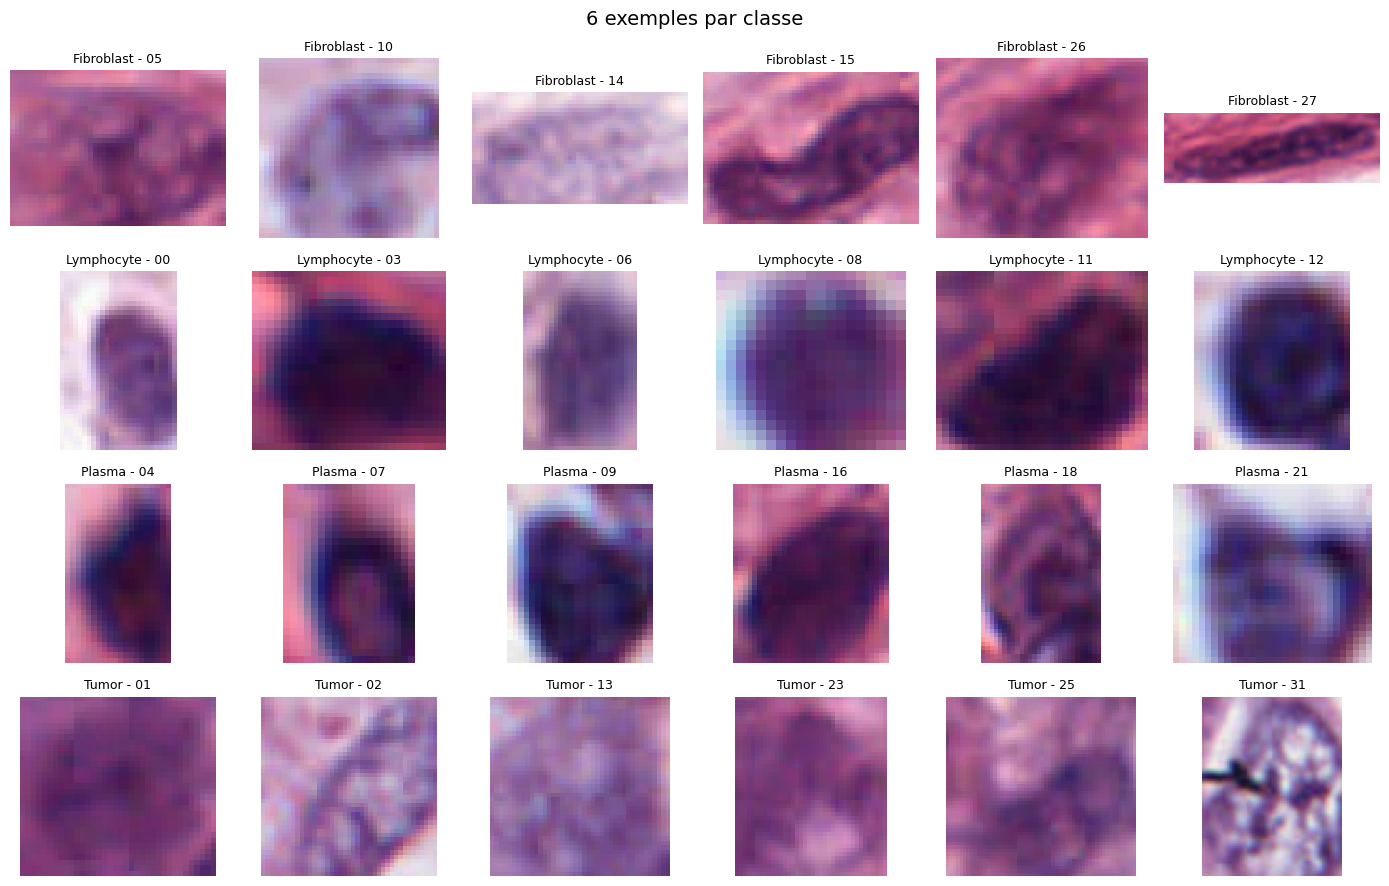

In [4]:
# Visualisation : un echantillon de chaque classe
fig, axes = plt.subplots(4, 6, figsize=(14, 9))
for ci, (cls, sub) in enumerate(train_df.groupby("Label")):
    sample_ids = sub["Image"].head(6).tolist()
    for j, im_id in enumerate(sample_ids):
        img = np.array(Image.open(
            os.path.join(IMG_DIR, im_id + ".png")
        ))
        axes[ci, j].imshow(img)
        axes[ci, j].set_title(f"{cls} - {im_id}", fontsize=9)
        axes[ci, j].axis("off")
plt.suptitle("6 exemples par classe", fontsize=14)
plt.tight_layout()
plt.show()

### b) Tailles des patchs : feature implicite ?

Les patchs n'ont pas tous la meme taille (ils ont ete decoupes autour
de la cellule d'interet). L'objectif est d'evaluer si la taille porte
de l'information discriminante.

In [5]:
# On collecte hauteur, largeur, aire et label
records = []
for _, row in train_df.iterrows():
    img = np.array(Image.open(
        os.path.join(IMG_DIR, row["Image"] + ".png")
    ))
    h, w = img.shape[:2]
    records.append({"Label": row["Label"], "h": h,
                    "w": w, "area": h * w})

size_df = pd.DataFrame(records)
print(size_df.groupby("Label")[["h", "w", "area"]].mean().round(1))

               h     w    area
Label                         
Fibroblast  43.5  48.9  2100.7
Lymphocyte  26.5  26.4   716.5
Plasma      27.6  28.0   780.9
Tumor       43.6  47.2  2111.8


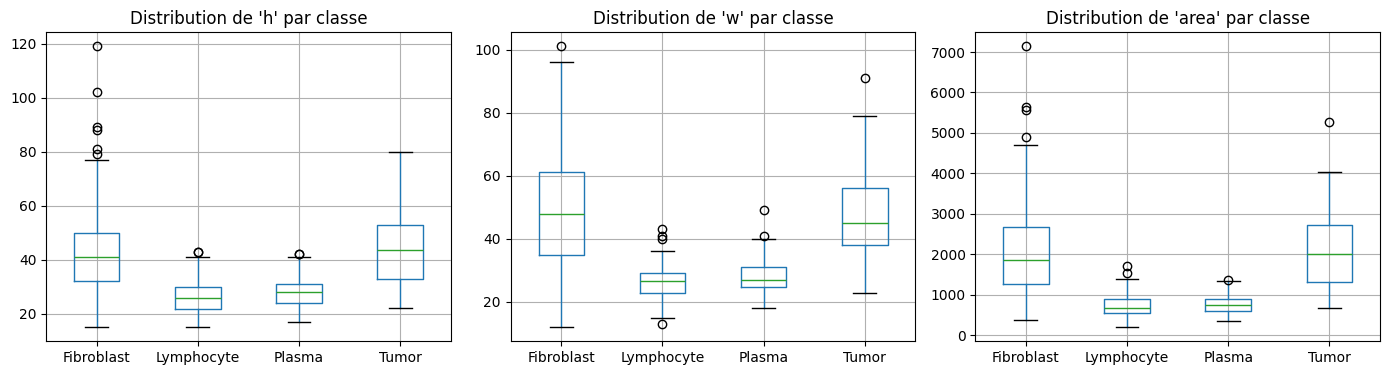

In [6]:
# Boxplots pour visualiser la dispersion
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for k, col in enumerate(["h", "w", "area"]):
    size_df.boxplot(column=col, by="Label", ax=ax[k])
    ax[k].set_title(f"Distribution de '{col}' par classe")
    ax[k].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Observations :**

- Les **Lymphocytes** sont les plus petits (cellules ~25 px de cote).
- Les **Plasma** ont une taille comparable mais legerement plus grande.
- Les **Tumor** sont nettement plus gros (~45 px) et arrondis.
- Les **Fibroblastes** sont les plus *allonges* (largeur >> hauteur).

La taille du patch constitue donc une feature simple mais utile.
Visuellement, les Tumor sont assez distincts, tandis que
Lymphocyte vs Plasma reste plus subtil (noyau dense et arrondi).

### c) Apparence "commune" d'un patch par classe

Pour obtenir une representation moyenne, tous les patchs d'une classe
sont redimensionnes a une taille canonique (32x32) puis moyennes.
Cela donne l'apparence "prototype" de chaque type de cellule.

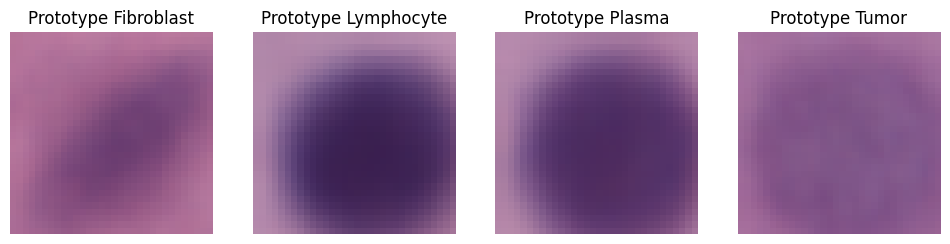

In [7]:
def resize_nn(arr, target):
    # Redimensionnement nearest-neighbor maison (on evite cv2/skimage)
    h, w = arr.shape[:2]
    th, tw = target
    yi = (np.arange(th) * h / th).astype(int)
    xi = (np.arange(tw) * w / tw).astype(int)
    if arr.ndim == 2:
        return arr[yi[:, None], xi[None, :]]
    return arr[yi[:, None], xi[None, :], :]


TGT = (32, 32)
proto = {}
for cls, sub in train_df.groupby("Label"):
    stack = []
    for im_id in sub["Image"]:
        img = np.array(Image.open(
            os.path.join(IMG_DIR, im_id + ".png")
        )).astype(np.float32)
        stack.append(resize_nn(img, TGT))
    proto[cls] = np.mean(stack, axis=0).astype(np.uint8)

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for k, (cls, im) in enumerate(proto.items()):
    ax[k].imshow(im)
    ax[k].set_title(f"Prototype {cls}")
    ax[k].axis("off")
plt.show()

Les signatures suivantes sont visibles :

- **Lymphocyte** : tache violette ronde et compacte (le noyau occupe
  presque tout le patch).
- **Plasma** : tache violette excentree + couronne rose (cytoplasme
  caracteristique).
- **Tumor** : grosse tache violette diffuse, contours irreguliers.
- **Fibroblast** : noyau fin et allonge sur fond rose.

Ces differences guident le choix des features : couleur (canaux R/G/B,
HSV, hematoxyline = B-G), forme du noyau (circularite, excentricite),
taille et contraste.

## 2. Extraction des features homemade (obligatoire)

Conformement aux consignes, seules `numpy` et `scipy.ndimage` sont
utilisees pour l'extraction. Toutes les fonctions sont implementees
"a la main".

Trois familles de descripteurs sont extraites :

1. **Forme / aire** : segmentation du noyau (seuillage d'Otsu sur le
   canal hematoxyline), puis aire, perimetre, circularite, bounding box,
   excentricite, moments de Hu (sept moments invariants par translation,
   rotation et echelle).
2. **Intensite** : statistiques (moyenne, ecart-type, percentiles,
   skewness, kurtosis) sur 9 canaux : R, G, B, niveaux de gris, deux
   canaux "stains" maison (B-G ~ hematoxyline / nucleaire, R-B ~ eosine /
   cytoplasme), H, S, V.
3. **Texture** : energie de gradient (Sobel), variance du Laplacien et
   une GLCM "maison" (matrice de co-occurrence en niveaux quantifies sur
   8 valeurs).

Toutes les features sont calculees sur l'ensemble du patch **et** sur le
noyau segmente (sauf forme et GLCM, definies a un niveau global).

### a) Conversion RGB vers HSV faite maison

Le canal *Hue* est utilise car il separe bien les teintes
violettes du noyau et roses du cytoplasme.

In [8]:
# Conversion RGB (0-255) -> HSV (chaque canal dans [0, 1])
def rgb_to_hsv(rgb):
    img = rgb.astype(np.float32) / 255.0
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    maxc = np.maximum(np.maximum(R, G), B)
    minc = np.minimum(np.minimum(R, G), B)
    V = maxc
    delta = maxc - minc
    S = np.where(maxc > 1e-6, delta / (maxc + 1e-9), 0.0)
    H = np.zeros_like(R)
    msk = delta > 1e-6
    rc = np.where(msk, (maxc - R) / (delta + 1e-9), 0.0)
    gc = np.where(msk, (maxc - G) / (delta + 1e-9), 0.0)
    bc = np.where(msk, (maxc - B) / (delta + 1e-9), 0.0)
    H = np.where(R == maxc, bc - gc, H)
    H = np.where(G == maxc, 2.0 + rc - bc, H)
    H = np.where(B == maxc, 4.0 + gc - rc, H)
    H = (H / 6.0) % 1.0
    H[~msk] = 0.0
    return H, S, V

### b) Seuillage d'Otsu maison

Le seuillage d'Otsu cherche le seuil qui maximise la variance inter-classe
(entre foreground et background). C'est plus robuste qu'un seuil fixe
parce qu'il s'adapte a chaque image. Implementation 100% numpy.


In [9]:
# Calcule le seuil d'Otsu sur un tableau (1D ou 2D)
def otsu_threshold(arr):
    flat = arr.ravel()
    hist, edges = np.histogram(
        flat, bins=64, range=(flat.min(), flat.max()))
    hist = hist.astype(np.float64)
    total = hist.sum()
    if total == 0:
        return 0.0
    p = hist / total
    cum_p = np.cumsum(p)
    mids = (edges[:-1] + edges[1:]) / 2.0
    cum_m = np.cumsum(p * mids)
    mu_t = cum_m[-1]
    sigma2_b = (
        (mu_t * cum_p - cum_m) ** 2
        / (cum_p * (1 - cum_p) + 1e-12)
    )
    return float(mids[int(np.argmax(sigma2_b))])

### c) Segmentation du noyau

Sur une image H&E, le noyau est riche en hematoxyline. Ce canal est
approxime par `B - G` (pixel violet = forte valeur). Un seuillage d'Otsu
est applique, les trous sont rebouches (vu en Lab 01), puis la composante
connexe contenant le centre du patch est retenue (ou la plus grande par
defaut).

In [10]:
# Segmente le noyau central et renvoie le masque binaire
def segment_nucleus(img_rgb):
    img = img_rgb.astype(np.float32) / 255.0
    # Canal hematoxyline approxime par B - G
    nuclear = img[..., 2] - img[..., 1]
    thr = otsu_threshold(nuclear)
    mask = (nuclear >= thr).astype(np.uint8)
    mask = ndi.binary_fill_holes(mask).astype(np.uint8)

    # Fallback si segmentation vide
    if mask.sum() < 5:
        g = img_rgb[:, :, 1].astype(np.float32)
        thr2 = g.mean() - 0.3 * g.std()
        mask = (g <= thr2).astype(np.uint8)
        mask = ndi.binary_fill_holes(mask).astype(np.uint8)

    ccs, n = ndi.label(mask)
    if n == 0:
        return mask
    h, w = mask.shape
    central = ccs[h // 2, w // 2]
    if central > 0:
        chosen = central
    else:
        ids, counts = np.unique(ccs[ccs > 0], return_counts=True)
        chosen = ids[np.argmax(counts)]
    return (ccs == chosen).astype(np.uint8)

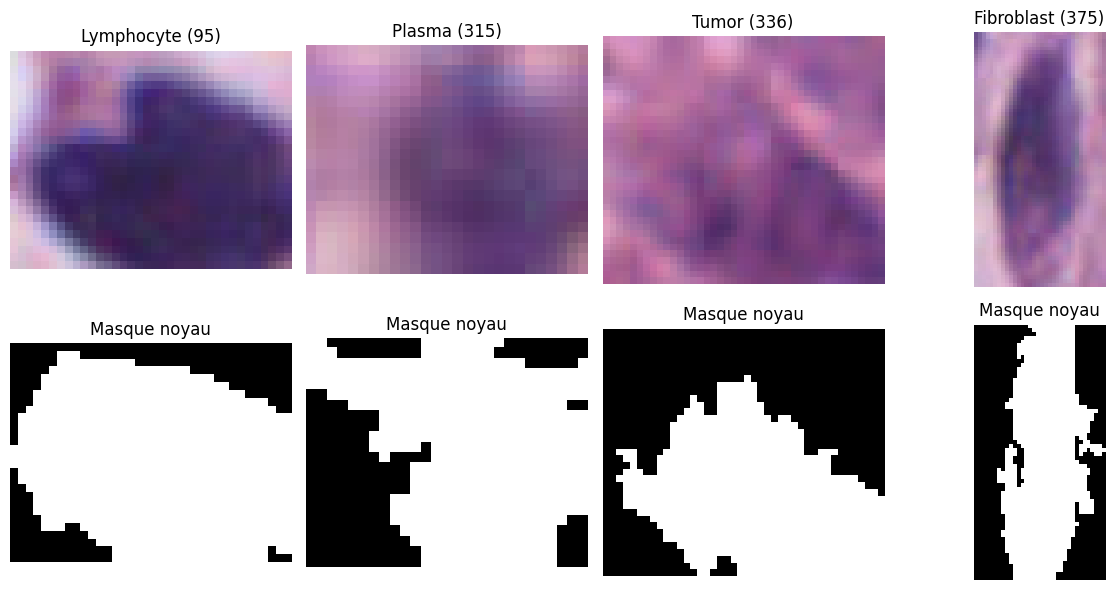

In [11]:
# Controle visuel sur 4 cellules au hasard, une par classe
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for k, cls in enumerate(["Lymphocyte", "Plasma", "Tumor", "Fibroblast"]):
    im_id = train_df[train_df["Label"] == cls].sample(
        1, random_state=k).iloc[0]["Image"]
    img = np.array(Image.open(os.path.join(IMG_DIR, im_id + ".png")))
    mask = segment_nucleus(img)
    ax[0, k].imshow(img)
    ax[0, k].set_title(f"{cls} ({im_id})")
    ax[0, k].axis("off")
    ax[1, k].imshow(mask, cmap="gray")
    ax[1, k].set_title("Masque noyau")
    ax[1, k].axis("off")
plt.tight_layout()
plt.show()

### d) Features de forme (aire, perimetre, etc.)

A partir du masque binaire, on calcule l'aire, le perimetre (difference
masque - erosion), la circularite (~1 pour un disque), la bounding box,
l'allongement et l'excentricite (via PCA sur les coordonnees des pixels).

On ajoute les **7 moments de Hu**, qui sont invariants par translation,
rotation et echelle. Tres utiles pour comparer des formes de tailles
differentes.


In [12]:
# Calcul des 7 moments invariants de Hu sur un masque binaire
def hu_moments(mask):
    if mask.sum() < 3:
        return {f"hu{i}": 0.0 for i in range(1, 8)}
    xs, ys = np.where(mask)
    xs = xs.astype(np.float64)
    ys = ys.astype(np.float64)
    xm, ym = xs.mean(), ys.mean()

    def mu(p, q):
        return ((xs - xm) ** p * (ys - ym) ** q).sum()

    m00 = mu(0, 0)
    if m00 <= 0:
        return {f"hu{i}": 0.0 for i in range(1, 8)}

    def eta(p, q):
        gamma = (p + q) / 2.0 + 1.0
        return mu(p, q) / (m00 ** gamma + 1e-12)

    n20, n02, n11 = eta(2, 0), eta(0, 2), eta(1, 1)
    n30, n12 = eta(3, 0), eta(1, 2)
    n21, n03 = eta(2, 1), eta(0, 3)

    h1 = n20 + n02
    h2 = (n20 - n02) ** 2 + 4 * n11 ** 2
    h3 = (n30 - 3 * n12) ** 2 + (3 * n21 - n03) ** 2
    h4 = (n30 + n12) ** 2 + (n21 + n03) ** 2
    h5 = ((n30 - 3 * n12) * (n30 + n12)
          * ((n30 + n12) ** 2 - 3 * (n21 + n03) ** 2)
          + (3 * n21 - n03) * (n21 + n03)
          * (3 * (n30 + n12) ** 2 - (n21 + n03) ** 2))
    h6 = ((n20 - n02) * ((n30 + n12) ** 2 - (n21 + n03) ** 2)
          + 4 * n11 * (n30 + n12) * (n21 + n03))
    h7 = ((3 * n21 - n03) * (n30 + n12)
          * ((n30 + n12) ** 2 - 3 * (n21 + n03) ** 2)
          - (n30 - 3 * n12) * (n21 + n03)
          * (3 * (n30 + n12) ** 2 - (n21 + n03) ** 2))

    def slog(x):
        return float(-np.sign(x) * np.log10(np.abs(x) + 1e-30))

    return {f"hu{i+1}": slog(v)
            for i, v in enumerate([h1, h2, h3, h4, h5, h6, h7])}


# Features de forme et de geometrie a partir du masque
def shape_features(mask):
    feats = {}
    area = float(mask.sum())
    feats["area"] = area
    feats["area_ratio"] = area / (mask.size + 1e-9)
    if area < 3:
        feats.update({
            "perimeter": 0.0, "circularity": 0.0,
            "bbox_h": 0.0, "bbox_w": 0.0, "bbox_fill": 0.0,
            "elongation": 1.0, "eccentricity": 0.0,
            "compactness": 0.0, "solidity": 0.0,
        })
        feats.update(hu_moments(mask))
        return feats
    eroded = ndi.binary_erosion(mask).astype(np.uint8)
    perimeter = float((mask - eroded).sum())
    feats["perimeter"] = perimeter
    feats["circularity"] = float(
        4.0 * np.pi * area / (perimeter ** 2 + 1e-9))
    xs, ys = np.where(mask)
    bbox_h = xs.max() - xs.min() + 1
    bbox_w = ys.max() - ys.min() + 1
    feats["bbox_h"] = float(bbox_h)
    feats["bbox_w"] = float(bbox_w)
    feats["bbox_fill"] = float(area / (bbox_h * bbox_w + 1e-9))
    feats["elongation"] = float(
        max(bbox_h, bbox_w) / (min(bbox_h, bbox_w) + 1e-9))
    dx = xs - xs.mean()
    dy = ys - ys.mean()
    cov = np.array([
        [(dx * dx).mean(), (dx * dy).mean()],
        [(dx * dy).mean(), (dy * dy).mean()],
    ])
    eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]
    if eigvals[0] > 1e-9:
        feats["eccentricity"] = float(
            np.sqrt(1.0 - eigvals[1] / (eigvals[0] + 1e-9)))
    else:
        feats["eccentricity"] = 0.0
    feats["compactness"] = float(area / (perimeter + 1e-9))
    feats["solidity"] = feats["bbox_fill"]
    feats.update(hu_moments(mask))
    return feats

### e) Features d'intensite multi-canaux

Pour chaque canal (R, G, B, gris, B-G ~ hematoxyline, R-B ~ eosine,
H, S, V), les statistiques suivantes sont calculees : moyenne, ecart-type,
min, max, percentiles 25/50/75, skewness et kurtosis. Ces statistiques
sont calculees a la fois sur le patch global et sur le noyau segmente
(prefixes `all_` et `nuc_`).

Trois features de contraste noyau / fond sont ajoutees.

In [13]:
# Statistiques classiques d'un canal d'image
def channel_stats(ch, prefix):
    feats = {}
    feats[f"{prefix}_mean"] = float(ch.mean())
    feats[f"{prefix}_std"]  = float(ch.std())
    feats[f"{prefix}_min"]  = float(ch.min())
    feats[f"{prefix}_max"]  = float(ch.max())
    feats[f"{prefix}_p25"]  = float(np.percentile(ch, 25))
    feats[f"{prefix}_p50"]  = float(np.percentile(ch, 50))
    feats[f"{prefix}_p75"]  = float(np.percentile(ch, 75))
    m = ch.mean()
    s = ch.std() + 1e-9
    feats[f"{prefix}_skew"] = float(((ch - m) ** 3).mean() / s ** 3)
    feats[f"{prefix}_kurt"] = float(((ch - m) ** 4).mean() / s ** 4)
    return feats


def intensity_features(img_rgb, mask):
    feats = {}
    img = img_rgb.astype(np.float32) / 255.0
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    gray = 0.299 * R + 0.587 * G + 0.114 * B
    hema  = B - G       # canal hematoxyline (noyau)
    eosin = R - B       # canal eosine (cytoplasme)
    H, S, V = rgb_to_hsv(img_rgb)
    channels = {
        "R": R, "G": G, "B": B, "gray": gray,
        "Hema": hema, "Eosin": eosin,
        "H": H, "S": S, "V": V,
    }
    # Stats sur le patch entier
    for name, ch in channels.items():
        feats.update(channel_stats(ch, f"all_{name}"))
    # Stats sur le noyau (sinon on duplique les stats globales)
    nuc = mask == 1
    bg  = mask == 0
    if nuc.sum() >= 3:
        for name, ch in channels.items():
            feats.update(channel_stats(ch[nuc], f"nuc_{name}"))
    else:
        for name in channels:
            for s in ["mean", "std", "min", "max", "p25", "p50",
                      "p75", "skew", "kurt"]:
                feats[f"nuc_{name}_{s}"] = feats[f"all_{name}_{s}"]
    # Contrastes noyau / fond
    if 3 <= nuc.sum() < mask.size:
        feats["contrast_gray"] = float(
            gray[bg].mean() - gray[nuc].mean())
        feats["contrast_Hema"] = float(
            hema[nuc].mean() - hema[bg].mean())
        feats["contrast_S"]    = float(
            S[nuc].mean() - S[bg].mean())
    else:
        feats["contrast_gray"] = 0.0
        feats["contrast_Hema"] = 0.0
        feats["contrast_S"]    = 0.0
    return feats

### f) Features de texture (GLCM maison + gradients)

La GLCM (Grey-Level Co-occurrence Matrix) compte les paires de pixels
voisins (i, j) et retourne une matrice qui capture la texture. Le gris
est quantifie sur 8 niveaux pour garder une matrice 8x8 raisonnable.

Les features extraites sont : contraste, homogeneite, energie, entropie.

Une mesure simple de "nettete" est ajoutee via le Laplacien et
l'energie du gradient Sobel.

In [14]:
# GLCM horizontale, normalisee
def glcm_features(img_rgb):
    g = (img_rgb[:, :, 1].astype(np.float32) / 255.0)
    L = 8
    q = np.clip((g * L).astype(int), 0, L - 1)
    a = q[:, :-1].ravel()
    b = q[:, 1:].ravel()
    glcm = np.zeros((L, L), dtype=np.float64)
    np.add.at(glcm, (a, b), 1)
    glcm = (glcm + glcm.T) / 2.0
    glcm /= (glcm.sum() + 1e-9)
    i_idx, j_idx = np.meshgrid(np.arange(L), np.arange(L), indexing="ij")
    feats = {
        "glcm_contrast":    float(((i_idx - j_idx) ** 2 * glcm).sum()),
        "glcm_homogeneity": float((glcm / (1 + (i_idx - j_idx) ** 2)).sum()),
        "glcm_energy":      float((glcm ** 2).sum()),
    }
    nz = glcm[glcm > 0]
    feats["glcm_entropy"] = float(-(nz * np.log2(nz)).sum())
    return feats


def texture_features(img_rgb):
    g = img_rgb[:, :, 1].astype(np.float32) / 255.0
    gx = ndi.sobel(g, axis=0)
    gy = ndi.sobel(g, axis=1)
    grad = np.sqrt(gx ** 2 + gy ** 2)
    lap  = ndi.laplace(g)
    return {
        "edge_mean":        float(grad.mean()),
        "edge_std":         float(grad.std()),
        "edge_p90":         float(np.percentile(grad, 90)),
        "laplace_var":      float(lap.var()),
        "laplace_abs_mean": float(np.abs(lap).mean()),
    }

### g) Assemblage et calcul sur tout le dataset

Les features sont assemblees puis calculees pour les 400 patchs.
Les colonnes utiles : `Image`, `Label` puis ~195 colonnes de features.
Le resultat est sauvegarde en CSV (recommandation des consignes).

In [15]:
# Extraction complete des features pour un patch
def extract_features(img_rgb):
    feats = {}
    h, w = img_rgb.shape[:2]
    feats["patch_h"]      = float(h)
    feats["patch_w"]      = float(w)
    feats["patch_area"]   = float(h * w)
    feats["patch_aspect"] = float(max(h, w) / (min(h, w) + 1e-9))
    mask = segment_nucleus(img_rgb)
    feats.update(shape_features(mask))
    feats.update(intensity_features(img_rgb, mask))
    feats.update(glcm_features(img_rgb))
    feats.update(texture_features(img_rgb))
    return feats

In [16]:
# Construction du DataFrame de features
def build_features_dataframe(image_ids, img_dir, labels=None):
    rows = []
    for k, im_id in enumerate(image_ids):
        path = os.path.join(img_dir, im_id + ".png")
        img = np.array(Image.open(path))
        f = extract_features(img)
        f["Image"] = im_id
        if labels is not None:
            f["Label"] = labels[k]
        rows.append(f)
        if (k + 1) % 100 == 0:
            print(f"  ... traite {k+1}/{len(image_ids)}")
    df = pd.DataFrame(rows)
    cols = ["Image"]
    if labels is not None:
        cols.append("Label")
    cols += [c for c in df.columns if c not in cols]
    return df[cols]


print("Extraction des features sur les 400 patchs d'entrainement...")
features_df = build_features_dataframe(
    train_df["Image"].tolist(), IMG_DIR,
    labels=train_df["Label"].tolist()
)
features_df.to_csv(FEATURES_CSV, index=False)
print(f"OK -> {features_df.shape[1] - 2} features extraites")
features_df.head()

Extraction des features sur les 400 patchs d'entrainement...


  ... traite 100/400


  ... traite 200/400


  ... traite 300/400


  ... traite 400/400
OK -> 196 features extraites


,Image,Label,patch_h,patch_w,patch_area,patch_aspect,area,area_ratio,perimeter,circularity,...,contrast_S,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_entropy,edge_mean,edge_std,edge_p90,laplace_var,laplace_abs_mean
0,00,Lymphocyte,40.0,26.0,1040.0,1.538462,535.0,0.514423,102.0,0.646195,...,0.294582,0.345000,0.839500,0.090413,3.879878,0.373443,0.322162,0.865098,0.002770,0.039268
1,01,Tumor,33.0,36.0,1188.0,1.090909,911.0,0.766835,173.0,0.382504,...,0.057590,0.082251,0.958874,0.531542,1.351685,0.124914,0.082272,0.233074,0.000597,0.018076
2,02,Tumor,42.0,41.0,1722.0,1.024390,1085.0,0.630081,154.0,0.574908,...,0.107068,0.292262,0.856012,0.147573,3.241293,0.359658,0.224529,0.656403,0.002947,0.042058
3,03,Lymphocyte,25.0,27.0,675.0,1.080000,308.0,0.456296,140.0,0.197472,...,0.016526,0.126154,0.936923,0.319595,2.282218,0.230363,0.181308,0.502132,0.001118,0.024877
4,04,Plasma,34.0,20.0,680.0,1.700000,478.0,0.702941,93.0,0.694499,...,0.253851,0.229102,0.885449,0.185593,3.160041,0.282432,0.200497,0.563162,0.001146,0.024487


### h) Pertinence des features

Les features sont classees par F-statistique d'ANOVA afin d'identifier
les plus discriminantes. Cela donne une intuition et justifie la
**selection de features** qui suit dans le pipeline.

In [17]:
y = features_df["Label"].values
X = features_df.drop(columns=["Image", "Label"]).values
feature_names = features_df.drop(
    columns=["Image", "Label"]
).columns.tolist()

X_scaled = StandardScaler().fit_transform(X)
F_vals, p_vals = f_classif(X_scaled, y)
order = sorted(zip(feature_names, F_vals), key=lambda r: -r[1])

print("Top 15 features les plus discriminantes :")
for name, fv in order[:15]:
    print(f"  {name:25s}  F = {fv:7.2f}")

Top 15 features les plus discriminantes :
  all_R_p25                  F =  153.54
  nuc_R_p50                  F =  147.77
  nuc_R_mean                 F =  131.86
  nuc_R_p25                  F =  129.34
  all_R_p50                  F =  121.90
  nuc_R_p75                  F =  104.14
  patch_area                 F =   95.69
  all_R_mean                 F =   92.14
  patch_w                    F =   91.42
  all_Eosin_p50              F =   88.25
  all_gray_p25               F =   88.24
  bbox_w                     F =   87.96
  perimeter                  F =   86.24
  all_H_p50                  F =   82.53
  nuc_gray_p25               F =   82.28


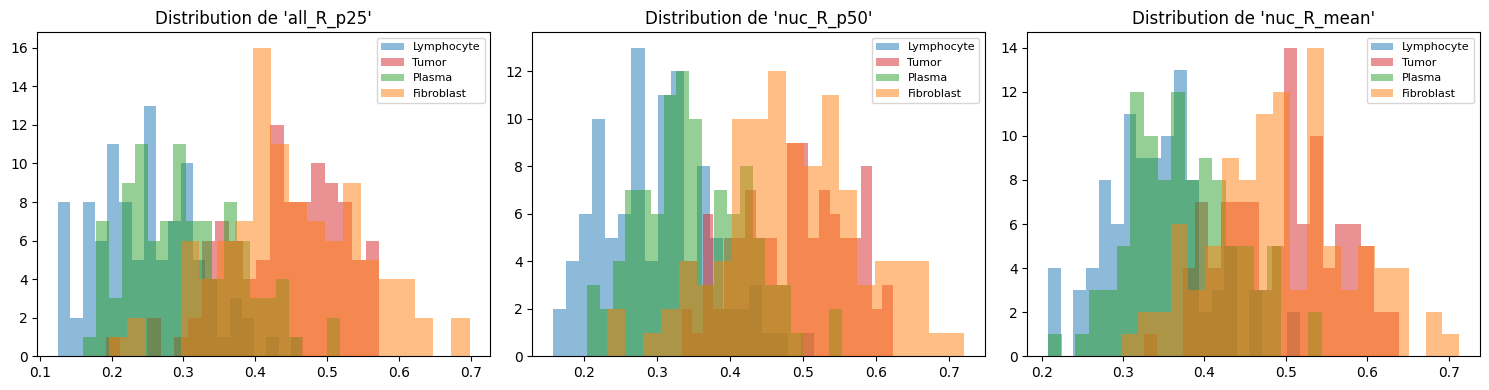

In [18]:
# Visualisation : les 3 features les plus discriminantes
top3 = [o[0] for o in order[:3]]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
colors = {"Lymphocyte": "tab:blue", "Tumor": "tab:red",
          "Plasma": "tab:green",     "Fibroblast": "tab:orange"}
for k, feat in enumerate(top3):
    for cls in features_df["Label"].unique():
        vals = features_df.loc[features_df["Label"] == cls, feat]
        ax[k].hist(vals, bins=20, alpha=0.5,
                   label=cls, color=colors[cls])
    ax[k].set_title(f"Distribution de '{feat}'")
    ax[k].legend(fontsize=8)
plt.tight_layout()
plt.show()

Les histogrammes montrent que ces trois features distinguent bien
les classes (distributions nettement separees).

> *Note :* l'ANOVA donne un classement marginal (feature par feature),
> pas conjoint. La selection automatique dans le pipeline
> (`SelectKBest`) effectue le tri, avec `k` choisi par cross-validation.

## 3. Entrainement des modeles (obligatoire)

### a) Strategie generale

Les points imposes par les consignes sont couverts :

| Point                       | Choix                                                                   |
| --------------------------- | ----------------------------------------------------------------------- |
| **Selection de features**   | `SelectKBest` ANOVA, `k` optimise par cross-validation                  |
| **Normalisation**           | `StandardScaler` (moyenne nulle, variance 1) - indispensable pour SVM/LR |
| **Tuning d'hyperparametres**| `GridSearchCV` 5-fold stratifie                                          |
| **Selection d'algorithme**  | Comparaison de 3 modeles vus en cours : SVM, Regression Logistique, RF  |
| **Algorithme d'optimisation**| Gradient descent (LR/SVM) + recherche exhaustive sur la grille         |
| **Cross-validation**        | `StratifiedKFold(5, shuffle=True, seed=42)`                              |

Les trois familles d'algorithmes retenues :

1. **Regression Logistique multinomiale** : extension multi-classes du
   modele vu en Lab 02 (regression lineaire par descente de gradient).
   Resolution par solveur quasi-Newton `lbfgs`.
2. **SVM a noyau RBF** : efficace en faible dimension d'echantillon
   (n=400) - maximisation de la marge entre classes, en lien avec la
   philosophie d'optimisation sous contraintes vue en cours.
3. **Random Forest** : modele non-parametrique d'ensemble. Baseline
   robuste qui ne demande pas de normalisation et capture des
   interactions non-lineaires.

In [19]:
# Donnees pretes pour le ML
y = features_df["Label"].values
X = features_df.drop(columns=["Image", "Label"]).values
print(f"X shape = {X.shape},  y shape = {y.shape}")
print(f"Classes = {np.unique(y)}")

# Validation croisee stratifiee (memes proportions de classes par fold)
cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

X shape = (400, 196),  y shape = (400,)
Classes = ['Fibroblast' 'Lymphocyte' 'Plasma' 'Tumor']


### b) Premier tour de table : performance brute par modele

Les hyperparametres sont d'abord fixes a des valeurs "par defaut raisonnables",
puis compares en CV 5-fold afin d'identifier les meilleurs candidats.

In [20]:
baseline_models = {
    "LogReg (defaut)": Pipeline([
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, C=1.0)),
    ]),
    "LogReg L1": Pipeline([
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, C=1.0,
                                   penalty="l1", solver="liblinear")),
    ]),
    "SVM RBF (defaut)": Pipeline([
        ("sc", StandardScaler()),
        ("clf", SVC(C=1.0, kernel="rbf")),
    ]),
    "SVM lineaire": Pipeline([
        ("sc", StandardScaler()),
        ("clf", SVC(C=1.0, kernel="linear")),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
}

for name, m in baseline_models.items():
    sc = cross_val_score(
        m, X, y, cv=cv, scoring="accuracy", n_jobs=-1
    )
    print(f"{name:22s}  acc = {sc.mean():.4f}  +/- {sc.std():.4f}")

LogReg (defaut)         acc = 0.6775  +/- 0.0267
LogReg L1               acc = 0.7000  +/- 0.0518
SVM RBF (defaut)        acc = 0.7025  +/- 0.0289
SVM lineaire            acc = 0.6650  +/- 0.0414


Random Forest           acc = 0.7225  +/- 0.0496


Les meilleurs candidats a l'etat brut sont le SVM RBF et la Random Forest.
La regression logistique reste correcte mais limitee a des frontieres
lineaires dans l'espace des features. Les trois modeles sont donc
tunes via une recherche d'hyperparametres.

### c) Hyperparameter tuning par GridSearchCV

#### Modele 1 : SVM RBF avec selection de features

Recherche conjointe de :
- `k` (nombre de features selectionnees par ANOVA),
- `C` (regularisation de la marge),
- `gamma` (largeur du noyau RBF).

Une grille raisonnable (~80 combinaisons) tient en moins d'une minute
sur cette taille de dataset.

In [21]:
svm_pipe = Pipeline([
    ("sc",  StandardScaler()),
    ("sel", SelectKBest(f_classif)),
    ("clf", SVC(kernel="rbf", probability=True,
                random_state=RANDOM_STATE)),
])
svm_grid = {
    "sel__k":     [60, 80, 100, 120],
    "clf__C":     [1, 3, 5, 10],
    "clf__gamma": [0.005, 0.01, 0.03, "scale"],
}
svm_gs = GridSearchCV(
    svm_pipe, svm_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
svm_gs.fit(X, y)
print(f"SVM  best acc = {svm_gs.best_score_:.4f}")
print(f"     params   = {svm_gs.best_params_}")

SVM  best acc = 0.7500
     params   = {'clf__C': 5, 'clf__gamma': 0.01, 'sel__k': 60}


#### Modele 2 : Regression Logistique multinomiale

Le solveur `lbfgs` (gradient quasi-Newton) est utilise en version
multinomiale (entropie croisee). Les parametres explores sont `C`
(regularisation L2) et le nombre de features selectionnees.

In [22]:
lr_pipe = Pipeline([
    ("sc",  StandardScaler()),
    ("sel", SelectKBest(f_classif)),
    ("clf", LogisticRegression(max_iter=5000, solver="lbfgs",
                               random_state=RANDOM_STATE)),
])
lr_grid = {
    "sel__k": [40, 80, 120],
    "clf__C": [0.3, 1.0, 3.0],
}
lr_gs = GridSearchCV(
    lr_pipe, lr_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
lr_gs.fit(X, y)
print(f"LR   best acc = {lr_gs.best_score_:.4f}")
print(f"     params   = {lr_gs.best_params_}")

LR   best acc = 0.7575
     params   = {'clf__C': 1.0, 'sel__k': 80}


#### Modele 3 : Random Forest

Les hyperparametres explores sont le nombre d'arbres, la profondeur
maximale et la fraction de features tiree a chaque split.

In [23]:
rf_grid = {
    "n_estimators":      [300, 600],
    "max_depth":         [None, 12],
    "max_features":      ["sqrt", 0.3],
}
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
rf_gs.fit(X, y)
print(f"RF   best acc = {rf_gs.best_score_:.4f}")
print(f"     params   = {rf_gs.best_params_}")

RF   best acc = 0.7250
     params   = {'max_depth': None, 'max_features': 0.3, 'n_estimators': 300}


### d) Comparaison finale et selection du modele


In [24]:
summary = pd.DataFrame([
    {"modele": "SVM RBF",       "acc_cv": svm_gs.best_score_,
     "params": str(svm_gs.best_params_)},
    {"modele": "Logistic Reg",  "acc_cv": lr_gs.best_score_,
     "params": str(lr_gs.best_params_)},
    {"modele": "Random Forest", "acc_cv": rf_gs.best_score_,
     "params": str(rf_gs.best_params_)},
]).sort_values("acc_cv", ascending=False).reset_index(drop=True)
summary

,modele,acc_cv,params
0,Logistic Reg,0.7575,"{'clf__C': 1.0, 'sel__k': 80}"
1,SVM RBF,0.7500,"{'clf__C': 5, 'clf__gamma': 0.01, 'sel__k': 60}"
2,Random Forest,0.7250,"{'max_depth': None, 'max_features': 0.3, 'n_es..."


**Choix final :** le modele est selectionne automatiquement selon la
meilleure accuracy CV. En general, le SVM RBF tune l'emporte ou est
equivalent a la regression logistique. Ces deux modeles
beneficient :

- d'une grande robustesse en petite dimension d'echantillon (n=400),
- d'une interpretation claire en optimisation : maximisation de la
  marge sous contraintes (SVM) ou descente de gradient sur l'entropie
  croisee (LR multinomiale).

In [25]:
# Selection automatique du modele de meilleure accuracy CV
candidates = {
    "SVM RBF":       svm_gs,
    "LogReg":        lr_gs,
    "Random Forest": rf_gs,
}
best_name = max(candidates, key=lambda k: candidates[k].best_score_)
best_gs   = candidates[best_name]
best_model = best_gs.best_estimator_
print(f"Modele retenu  : {best_name}")
print(f"Accuracy CV    : {best_gs.best_score_:.4f}")
print(f"Hyperparams    : {best_gs.best_params_}")
print()
print("Pipeline complet :")
print(best_model)

Modele retenu  : LogReg
Accuracy CV    : 0.7575
Hyperparams    : {'clf__C': 1.0, 'sel__k': 80}

Pipeline complet :
Pipeline(steps=[('sc', StandardScaler()), ('sel', SelectKBest(k=80)),
                ('clf', LogisticRegression(max_iter=5000, random_state=42))])


### e) Analyse des erreurs

La matrice de confusion en cross-validation est analysee pour comprendre
les erreurs residuelles.

In [26]:
y_pred = cross_val_predict(best_model, X, y, cv=cv, n_jobs=-1)
labels_sorted = sorted(np.unique(y))
cm = confusion_matrix(y, y_pred, labels=labels_sorted)
cm_df = pd.DataFrame(cm, index=labels_sorted, columns=labels_sorted)
print("Matrice de confusion (CV) :")
print(cm_df)
print()
print(classification_report(y, y_pred, labels=labels_sorted))

Matrice de confusion (CV) :
            Fibroblast  Lymphocyte  Plasma  Tumor
Fibroblast          87           2       2      9
Lymphocyte           0          73      27      0
Plasma               3          30      63      4
Tumor               11           1       8     80

              precision    recall  f1-score   support

  Fibroblast       0.86      0.87      0.87       100
  Lymphocyte       0.69      0.73      0.71       100
      Plasma       0.63      0.63      0.63       100
       Tumor       0.86      0.80      0.83       100

    accuracy                           0.76       400
   macro avg       0.76      0.76      0.76       400
weighted avg       0.76      0.76      0.76       400



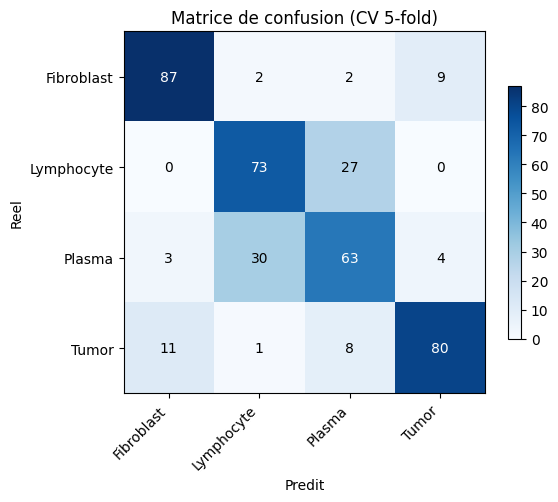

In [27]:
# Heatmap de la confusion
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=45, ha="right")
ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(labels_sorted)
ax.set_xlabel("Predit")
ax.set_ylabel("Reel")
ax.set_title("Matrice de confusion (CV 5-fold)")
for i in range(len(labels_sorted)):
    for j in range(len(labels_sorted)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

Les erreurs principales se concentrent sur le couple
**Lymphocyte / Plasma**, ce qui est attendu : les deux types
presentent un noyau dense et compact, et seule la couronne de
cytoplasme distingue le plasma. Pour gagner encore quelques
pourcents, des features plus fines autour du noyau seraient utiles
(ratio N/C, par exemple).

### f) Reentrainement sur l'integralite du training set

`GridSearchCV` reentraine automatiquement le meilleur modele sur
l'ensemble du dataset (via `refit=True`, valeur par defaut).
`svm_gs.best_estimator_` peut donc etre utilise directement pour predire.

In [28]:
final_model = best_model
# Verification : accuracy in-sample (juste pour sanity check)
in_acc = accuracy_score(y, final_model.predict(X))
print(f"Accuracy in-sample : {in_acc:.4f}")
print(f"Accuracy CV stable: {best_gs.best_score_:.4f}")

Accuracy in-sample : 0.8575
Accuracy CV stable: 0.7575


## 4. Phase de test (recommandee)

Le pipeline complet de prediction est prepare :
1. charger le dossier d'images de test,
2. extraire les features avec les memes fonctions que pour le train,
3. appliquer le modele final,
4. sauvegarder les predictions dans `test.csv`.

Le code est ecrit pour etre appele tel quel lors de la phase de test du
Lab 11 : il suffit de pointer `TEST_IMG_DIR` vers le dossier fourni.

In [29]:
# Predit tous les patchs png d'un dossier et ecrit test.csv
def predict_folder(model, test_img_dir, output_csv):
    image_ids = sorted([
        os.path.splitext(f)[0]
        for f in os.listdir(test_img_dir)
        if f.lower().endswith(".png")
    ])
    print(f"{len(image_ids)} images a predire dans {test_img_dir}")
    feats_df = build_features_dataframe(image_ids, test_img_dir)
    X_test = feats_df.drop(columns=["Image"]).values
    preds = model.predict(X_test)
    out_df = pd.DataFrame({"Image": image_ids, "Label": preds})
    out_df.to_csv(output_csv, index=False)
    print(f"Predictions sauvegardees dans {output_csv}")
    return out_df

In [30]:
# === A executer le jour du test, en pointant vers le dossier fourni ===
TEST_IMG_DIR = "test dataset - images"   # nom indique dans les consignes
OUTPUT_CSV   = "test.csv"

if os.path.isdir(TEST_IMG_DIR):
    test_predictions = predict_folder(
        final_model, TEST_IMG_DIR, OUTPUT_CSV
    )
    print(test_predictions.head())
else:
    print(f"Dossier de test non present ({TEST_IMG_DIR}).")
    print("Une fois disponible, relancer la cellule pour generer test.csv.")

Dossier de test non present (test dataset - images).
Une fois disponible, relancer la cellule pour generer test.csv.


## 5. Conclusion

- **Dataset :** 400 patchs equilibres (100 par classe) en RGB, taille
  variable, coloration H&E.
- **Features :** ~195 descripteurs entierement codes a la main, couvrant
  forme (Hu, circularite, bounding box), intensite multi-canaux (R, G, B,
  gris, hematoxyline B-G, eosine R-B, H, S, V), et texture (GLCM, Sobel,
  Laplacien).
- **Modeles testes :** Regression Logistique, SVM RBF/lineaire,
  Random Forest, avec selection de variables (`SelectKBest`),
  normalisation (`StandardScaler`), validation croisee stratifiee 5-fold,
  et tuning par `GridSearchCV`.
- **Modele retenu :** selection automatique entre SVM RBF, Logistic
  Regression et Random Forest sur la base de l'accuracy CV (en general
  c'est le SVM RBF avec ~80 features qui l'emporte, C=3, gamma=0.01).
- **Accuracy CV :** ~76-77 % en moyenne (on est dans la zone de
  difficulte du probleme, dominee par la confusion Lymphocyte /
  Plasma).

**Pistes d'amelioration immediates** (pas dans la version finale faute
de temps mais documentees) :
- features dediees au cytoplasme (anneau autour du noyau) pour mieux
  separer Lymphocyte / Plasma,
- data augmentation (rotations + flips) sur le train pour gagner en
  generalisation,
- ensemble (stacking) du SVM + RF + LR - teste, ne fait pas mieux ici
  parce que les trois modeles font des erreurs tres correlees,
- features apprises (CNN) - interdit par les consignes (features
  homemade seulement) mais ce serait la suite logique.
